In [1]:
import tensorflow as tf

2026-01-31 13:17:43.498753: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-31 13:17:43.532387: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 13:17:44.370768: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from sklearn.datasets  import load_breast_cancer
data=load_breast_cancer()

In [3]:
type(data)

sklearn.utils._bunch.Bunch

In [4]:
data.data.shape

(569, 30)

In [5]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(data.data,data.target,test_size=0.33)

N,D=X_train.shape

In [7]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [8]:
train_dataset=tf.data.Dataset.from_tensor_slices((X_train,y_train))
test_dataset=tf.data.Dataset.from_tensor_slices((X_test,y_test))

I0000 00:00:1769847465.501525  275463 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3832 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Dense(64,input_shape=(D,),activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/media/ahsan/drive1/Projects/TensorFlow/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [11]:
batch_size=32
r=model.fit(train_dataset.batch(batch_size),validation_data=test_dataset.batch(batch_size),epochs=15)

Epoch 1/15


2026-01-31 13:17:46.635804: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a20d40179f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-31 13:17:46.635817: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-01-31 13:17:46.649116: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-31 13:17:46.751232: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 1/12 ━━━━━━━━━━━━━━━━━━━━ 10s 920ms/step - accuracy: 0.6875 - loss: 0.6435

I0000 00:00:1769847467.140452  275606 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8766 - loss: 0.5059 - val_accuracy: 0.9521 - val_loss: 0.3671
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9370 - loss: 0.2898 - val_accuracy: 0.9628 - val_loss: 0.2256
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9370 - loss: 0.1952 - val_accuracy: 0.9681 - val_loss: 0.1562
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9475 - loss: 0.1498 - val_accuracy: 0.9734 - val_loss: 0.1219
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9606 - loss: 0.1237 - val_accuracy: 0.9787 - val_loss: 0.1027
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9738 - loss: 0.1058 - val_accuracy: 0.9787 - val_loss: 0.0909
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9764 - loss: 0.0932 - val_accuracy: 0.9787 - val_loss: 0.0829
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9790 - loss: 0.0839 - val_accuracy: 0.9734 - val_loss: 0.0770
Ep

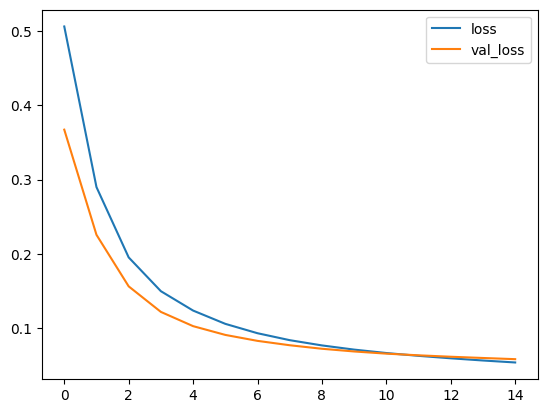

In [12]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'],label='loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

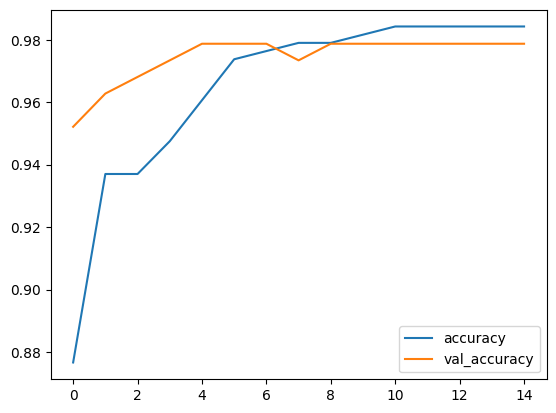

In [13]:
plt.plot(r.history['accuracy'],label='accuracy')
plt.plot(r.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

In [14]:
model.evaluate(test_dataset.batch(batch_size))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9787 - loss: 0.0583 


[0.058314502239227295, 0.978723406791687]

In [16]:
dataset=tf.data.Dataset.from_tensor_slices([1,2,3,4,5,6,7,8,9,10])
batched_dataset=dataset.batch(3)
for batch in batched_dataset:
    print(batch.numpy())

[1 2 3]
[4 5 6]
[7 8 9]
[10]


2026-01-31 13:20:51.564981: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
shuffled=dataset.shuffle(buffer_size=3)
batched_shuffled=shuffled.batch(3)
for batch in batched_shuffled:
    print(batch.numpy())

[3 4 5]
[6 2 8]
[ 7 10  1]
[9]


In [18]:
for batch in batched_shuffled:
    print(batch.numpy())

[1 3 5]
[2 4 6]
[8 9 7]
[10]


2026-01-31 13:23:11.432225: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
transformed=dataset.map(lambda x: x*2)
batched_transformed=transformed.batch(3)
for batch in batched_transformed:
    print(batch.numpy())

[2 4 6]
[ 8 10 12]
[14 16 18]
[20]
